In [18]:
%pip -q install aeon
%pip install "huggingface-hub>=1.23.0,<2.0"

import random
import time
import copy
import warnings

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from aeon.datasets import load_basic_motions
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score


from aeon.datasets import load_classification
from sklearn.preprocessing import LabelEncoder
from huggingface_hub import hf_hub_download


warnings.filterwarnings("ignore")

# Для небольших временных рядов один CPU-поток часто удобен
# и позволяет уменьшить накладные расходы на маленьких свёртках.
torch.set_num_threads(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 23.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 2.2.0
    Uninstalling huggingface_hub-2.2.0:
      Successfully uninstalled huggingface_hub-2.2.0
Устройство: cuda
GPU: Tesla T4


In [19]:
REPO_ID = "monster-monash/PAMAP2"
FOLD = 0  # можно выбрать 0, 1, 2, 3 или 4

# Скачиваем только необходимые файлы.
# Файлы кэшируются Hugging Face Hub, повторно
# скачивать их в той же среде обычно не требуется.
X_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="PAMAP2_X.npy",
    repo_type="dataset"
)

y_path = hf_hub_download(
    repo_id=REPO_ID,
    filename="PAMAP2_y.npy",
    repo_type="dataset"
)

fold_path = hf_hub_download(
    repo_id=REPO_ID,
    filename=f"test_indices_fold_{FOLD}.txt",
    repo_type="dataset"
)

print("Файлы загружены:")
print("X:", X_path)
print("y:", y_path)
print("Индексы test:", fold_path)

PAMAP2_X.npy: reconstructing file:   0%|          |  0.00B / 1.62GB            

PAMAP2_X.npy: downloading bytes:           |  0.00B            

PAMAP2_y.npy: reconstructing file:   0%|          |  0.00B /  311kB            

PAMAP2_y.npy: downloading bytes:           |  0.00B            

test_indices_fold_0.txt:   0%|          | 0.00/59.4k [00:00<?, ?B/s]

Файлы загружены:
X: /root/.cache/huggingface/hub/datasets--monster-monash--PAMAP2/snapshots/1436789378af3e8c2aee6d52547a47f423e0207b/PAMAP2_X.npy
y: /root/.cache/huggingface/hub/datasets--monster-monash--PAMAP2/snapshots/1436789378af3e8c2aee6d52547a47f423e0207b/PAMAP2_y.npy
Индексы test: /root/.cache/huggingface/hub/datasets--monster-monash--PAMAP2/snapshots/1436789378af3e8c2aee6d52547a47f423e0207b/test_indices_fold_0.txt


• Участники: 9 испытуемых (8 мужчин и 1 женщина; 8 правшей, 1 левша).
• Активности: 12 различных видов физической активности (включая ходьбу, бег, езду на велосипеде, игру в футбол, работу по дому, лежание, сидение и др.).
• Датчики:
  • 3 беспроводных инерциальных измерительных модуля (IMU) на доминирующем запястье, груди и лодыжке (работают с частотой 100 Гц; записывают температуру, 3D-акселерометр, 3D-гироскоп и 3D-магнитометр).

Задача: классифицировать активность

In [20]:
# mmap_mode='r' позволяет читать большой файл без
# загрузки всего массива в оперативную память сразу.
X_mmap = np.load(X_path, mmap_mode="r")
y_raw = np.asarray(np.load(y_path)).reshape(-1)

test_idx = np.asarray(
    np.loadtxt(fold_path, dtype=np.int64)
).reshape(-1)

assert X_mmap.ndim == 3
assert X_mmap.shape[0] == len(y_raw)

# Маска train: все объекты, не включённые в test fold.
is_train = np.ones(len(y_raw), dtype=bool)
is_train[test_idx] = False
train_idx = np.flatnonzero(is_train)

# Модели из нашего пайплайна ожидают float32
# и форму [число объектов, каналы, время].
X_train = np.asarray(X_mmap[train_idx], dtype=np.float32)
X_test = np.asarray(X_mmap[test_idx], dtype=np.float32)

y_train_raw = y_raw[train_idx]
y_test_raw = y_raw[test_idx]

# Преобразуем метки в непрерывный диапазон 0 ... n_classes-1.
encoder = LabelEncoder()
encoder.fit(y_raw)

y_train = encoder.transform(y_train_raw).astype(np.int64)
y_test = encoder.transform(y_test_raw).astype(np.int64)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)
print("Исходные метки классов:", encoder.classes_)

del X_mmap, y_raw, y_train_raw, y_test_raw, is_train
gc.collect()

Train: (28961, 52, 100) (28961,)
Test:  (9895, 52, 100) (9895,)
Исходные метки классов: [ 0  1  2  3  4  5  6  7  8  9 10 11]


163

In [21]:
n_channels = X_train.shape[1]
seq_len = X_train.shape[2]

channel_mean = np.zeros(
    (1, n_channels, 1), dtype=np.float32
)
channel_std = np.ones(
    (1, n_channels, 1), dtype=np.float32
)

for ch in range(n_channels):
    train_ch = X_train[:, ch, :]
    valid = np.isfinite(train_ch)

    if valid.any():
        mean = train_ch[valid].mean(dtype=np.float64)
        std = train_ch[valid].std(dtype=np.float64)
    else:
        mean, std = 0.0, 1.0

    if std < 1e-6 or not np.isfinite(std):
        std = 1.0

    # Замена некорректных значений с использованием train-статистик.
    train_ch[~valid] = mean

    test_ch = X_test[:, ch, :]
    test_ch[~np.isfinite(test_ch)] = mean

    channel_mean[0, ch, 0] = mean
    channel_std[0, ch, 0] = std

# In-place нормализация снижает дополнительный расход RAM.
X_train -= channel_mean
X_train /= channel_std

X_test -= channel_mean
X_test /= channel_std

n_classes = len(encoder.classes_)

print("Готово к обучению.")
print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Каналов:", n_channels)
print("Длина последовательности:", seq_len)
print("Классов:", n_classes)

print("\nРаспределение классов train:")
display(pd.Series(y_train).value_counts().sort_index().to_frame("count"))

print("Распределение классов test:")
display(pd.Series(y_test).value_counts().sort_index().to_frame("count"))

Готово к обучению.
Train: (28961, 52, 100)
Test: (9895, 52, 100)
Каналов: 52
Длина последовательности: 100
Классов: 12

Распределение классов train:


,count
0,2922
1,2747
2,2793
3,3485
4,1779
5,2337
6,2616
7,1665
8,1508
9,2693


Распределение классов test:


,count
0,930
1,956
2,1006
3,1289
4,185
5,956
6,1146
7,682
8,589
9,814


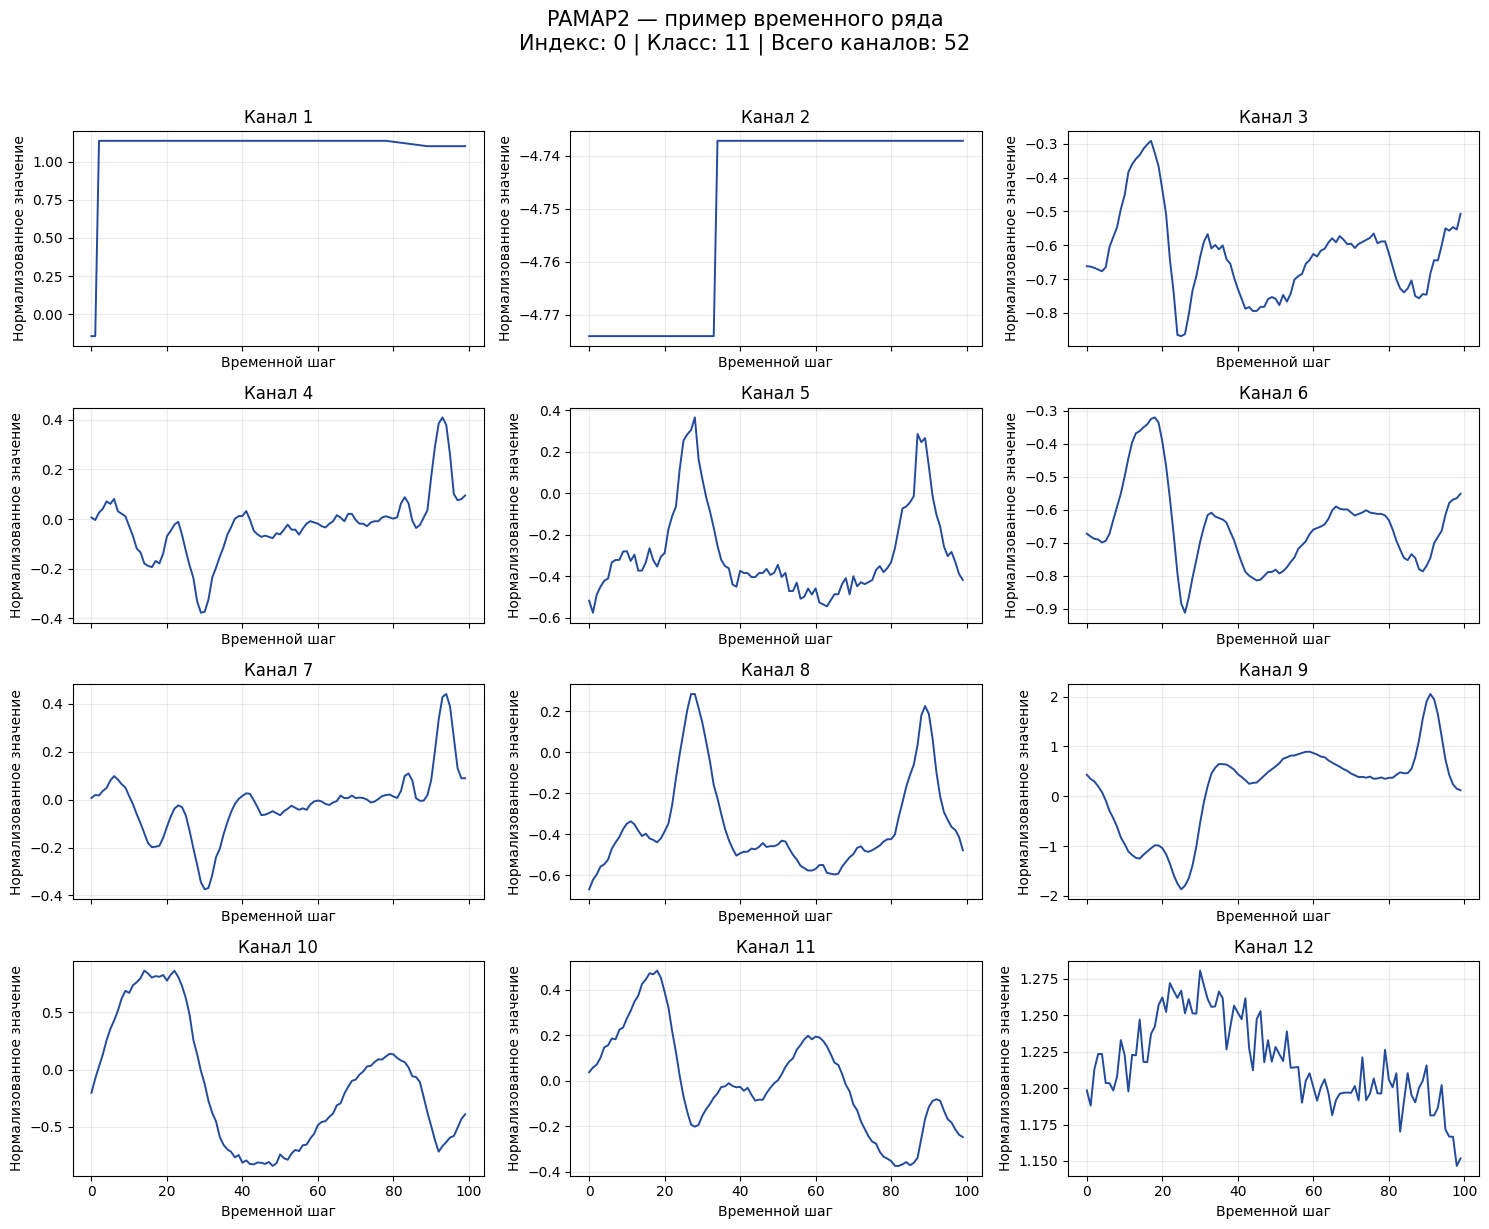

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Индекс последовательности
sample_idx = 0

# По умолчанию отображаем 12 каналов.
# Для отображения всех каналов используй:
# channels_to_plot = list(range(n_channels))
channels_to_plot = list(range(min(n_channels, 12)))

# Получаем исходное название класса
class_label = encoder.inverse_transform(
    [int(y_train[sample_idx])]
)[0]

# Динамически рассчитываем сетку графиков
ncols = 3
nrows = math.ceil(len(channels_to_plot) / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(15, 3 * nrows),
    sharex=True
)

axes = np.asarray(axes).reshape(-1)

for i, ch in enumerate(channels_to_plot):
    ax = axes[i]

    ax.plot(
        X_train[sample_idx, ch, :],
        linewidth=1.4,
        color="#234B9B"
    )

    ax.set_title(f"Канал {ch + 1}")
    ax.set_xlabel("Временной шаг")
    ax.set_ylabel("Нормализованное значение")
    ax.grid(alpha=0.25)

# Скрываем пустые ячейки сетки
for i in range(len(channels_to_plot), len(axes)):
    axes[i].set_visible(False)

fig.suptitle(
    f"PAMAP2 — пример временного ряда\n"
    f"Индекс: {sample_idx} | Класс: {class_label} | "
    f"Всего каналов: {n_channels}",
    fontsize=15,
    y=1.02
)

plt.tight_layout()
plt.show()

Данные получены с трёх инерциальных измерительных устройств (на запястье, груди и лодыжке), а также датчика сердечного ритма. Исходные измерения записывались с частотой 100 Гц. Датасет содержит записи девяти участников

In [27]:
# ---------- Общие функции для структурной репараметризации ----------

def count_parameters(model):
    """Число параметров модели, включая веса и смещения."""
    return sum(p.numel() for p in model.parameters())


def fuse_conv_bn(conv, bn):
    """
    Складывает Conv1d + BatchNorm1d в одну эквивалентную свёртку.
    Вызывать после model.eval(), когда BN использует running statistics.
    """
    w = conv.weight.detach()

    if conv.bias is None:
        conv_bias = torch.zeros(
            conv.out_channels, device=w.device, dtype=w.dtype
        )
    else:
        conv_bias = conv.bias.detach()

    scale = bn.weight.detach() / torch.sqrt(
        bn.running_var.detach() + bn.eps
    )

    fused_w = w * scale.reshape(-1, 1, 1)
    fused_b = (
        bn.bias.detach()
        + (conv_bias - bn.running_mean.detach()) * scale
    )

    return fused_w, fused_b


def fuse_identity_bn(bn, channels, kernel_size):
    """
    Представляет ветвь BatchNorm(x) как свёртку с identity-ядром
    и эквивалентным смещением.
    """
    scale = bn.weight.detach() / torch.sqrt(
        bn.running_var.detach() + bn.eps
    )

    weight = torch.zeros(
        channels, 1, kernel_size,
        device=scale.device,
        dtype=scale.dtype
    )
    weight[:, 0, kernel_size // 2] = scale

    bias = bn.bias.detach() - bn.running_mean.detach() * scale

    return weight, bias


def embed_kernel(weight, dilation, target_kernel_size):
    """
    Встраивает ядро с дилатацией в большое обычное ядро.
    Например, k=3, dilation=4 превращается в ядро длины 9
    с нулями между исходными коэффициентами.
    """
    effective_size = (weight.shape[-1] - 1) * dilation + 1

    expanded = torch.zeros(
        weight.shape[0],
        weight.shape[1],
        effective_size,
        device=weight.device,
        dtype=weight.dtype
    )
    expanded[:, :, ::dilation] = weight

    if effective_size > target_kernel_size:
        raise ValueError("Целевое ядро меньше эффективного размера ветви.")

    total_pad = target_kernel_size - effective_size
    left_pad = total_pad // 2
    right_pad = total_pad - left_pad

    return F.pad(expanded, (left_pad, right_pad))


def make_depthwise_conv(channels, kernel_size, weight, bias):
    """Создаёт обычную depthwise Conv1d с заданными слитыми весами."""
    conv = nn.Conv1d(
        channels,
        channels,
        kernel_size=kernel_size,
        padding=kernel_size // 2,
        groups=channels,
        bias=True
    ).to(device=weight.device, dtype=weight.dtype)

    with torch.no_grad():
        conv.weight.copy_(weight)
        conv.bias.copy_(bias)

    return conv


# ---------- Стандартный блок CNN ----------

class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation=1):
        super().__init__()
        padding = dilation * (kernel_size // 2)

        self.block = nn.Sequential(
            nn.Conv1d(
                in_channels,
                out_channels,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
                bias=False
            ),
            nn.BatchNorm1d(out_channels),
            nn.ReLU()
        )

    def forward(self, x):
        return self.block(x)


# ---------- Baseline: обычная 1D CNN ----------

class CNNBaseline(nn.Module):
    def __init__(self, in_channels, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            ConvBNReLU(in_channels, 32, kernel_size=7),
            nn.Dropout(0.10),

            ConvBNReLU(32, 48, kernel_size=5),
            nn.Dropout(0.10),

            ConvBNReLU(48, 64, kernel_size=3)
        )

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.25),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.head(x)


# ---------- IMP: остаточное смешивание каналов ----------

class InterChannelMessagePassing(nn.Module):
    def __init__(self, num_channels):
        super().__init__()
        self.channel_mix = nn.Linear(
            num_channels, num_channels, bias=False
        )

    def forward(self, x):
        # x: [batch, channels, time]
        # Linear работает по последней размерности,
        # поэтому временно меняем оси.
        x_t = x.transpose(1, 2)             # [batch, time, channels]
        x_t = x_t + self.channel_mix(x_t)    # остаточная передача сообщений
        return x_t.transpose(1, 2)


# ---------- SKB: короткие временные паттерны ----------

class SmallKernelBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels

        self.conv3 = nn.Conv1d(
            channels, channels, 3,
            padding=1, groups=channels, bias=False
        )
        self.bn3 = nn.BatchNorm1d(channels)

        self.conv1 = nn.Conv1d(
            channels, channels, 1,
            padding=0, groups=channels, bias=False
        )
        self.bn1 = nn.BatchNorm1d(channels)

        self.bn_identity = nn.BatchNorm1d(channels)

        self.reparam_conv = None
        self.is_reparam = False

    def forward(self, x):
        if self.is_reparam:
            return F.relu(self.reparam_conv(x))

        out = (
            self.bn3(self.conv3(x))
            + self.bn1(self.conv1(x))
            + self.bn_identity(x)
        )
        return F.relu(out)

    def reparameterize(self):
        if self.is_reparam:
            return

        w3, b3 = fuse_conv_bn(self.conv3, self.bn3)
        w1, b1 = fuse_conv_bn(self.conv1, self.bn1)
        wi, bi = fuse_identity_bn(
            self.bn_identity, self.channels, kernel_size=3
        )

        w3 = embed_kernel(w3, dilation=1, target_kernel_size=3)
        w1 = embed_kernel(w1, dilation=1, target_kernel_size=3)

        fused_w = w3 + w1 + wi
        fused_b = b3 + b1 + bi

        self.reparam_conv = make_depthwise_conv(
            self.channels, 3, fused_w, fused_b
        )

        # Удаляем исходные ветви, чтобы они не считались
        # частью deployment-модели.
        self.conv3 = None
        self.bn3 = None
        self.conv1 = None
        self.bn1 = None
        self.bn_identity = None

        self.is_reparam = True


# ---------- LKB: большой и многомасштабный контекст ----------

class MultiScaleLargeKernelBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels

        # Эффективные receptive fields: 3, 5, 9, 5.
        branch_specs = [
            (3, 1),
            (3, 2),
            (3, 4),
            (5, 1)
        ]

        self.branches = nn.ModuleList()

        for kernel_size, dilation in branch_specs:
            self.branches.append(
                nn.Sequential(
                    nn.Conv1d(
                        channels,
                        channels,
                        kernel_size=kernel_size,
                        padding=dilation * (kernel_size // 2),
                        dilation=dilation,
                        groups=channels,
                        bias=False
                    ),
                    nn.BatchNorm1d(channels)
                )
            )

        self.reparam_conv = None
        self.is_reparam = False
        self.target_kernel_size = 9

    def forward(self, x):
        if self.is_reparam:
            return F.relu(self.reparam_conv(x))

        out = x  # остаточная identity-ветвь
        for branch in self.branches:
            out = out + branch(x)

        return F.relu(out)

    def reparameterize(self):
        if self.is_reparam:
            return

        k = self.target_kernel_size

        fused_w = torch.zeros(
            self.channels, 1, k,
            device=next(self.parameters()).device,
            dtype=next(self.parameters()).dtype
        )
        fused_b = torch.zeros(
            self.channels,
            device=fused_w.device,
            dtype=fused_w.dtype
        )

        # Сливаем каждую Conv + BN и помещаем ядро в общий размер.
        for branch in self.branches:
            conv = branch[0]
            bn = branch[1]

            w, b = fuse_conv_bn(conv, bn)
            w = embed_kernel(
                w,
                dilation=conv.dilation[0],
                target_kernel_size=k
            )

            fused_w += w
            fused_b += b

        # Остаточная ветвь x — центральный коэффициент 1.
        fused_w[:, 0, k // 2] += 1.0

        self.reparam_conv = make_depthwise_conv(
            self.channels, k, fused_w, fused_b
        )
        self.branches = nn.ModuleList()
        self.is_reparam = True


# ---------- Ablation: одна временная шкала вместо LKB ----------

class SingleScaleBlock(nn.Module):
    def __init__(self, channels, kernel_size=5):
        super().__init__()
        self.channels = channels
        self.kernel_size = kernel_size

        self.conv = nn.Conv1d(
            channels, channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            groups=channels,
            bias=False
        )
        self.bn = nn.BatchNorm1d(channels)

        self.reparam_conv = None
        self.is_reparam = False

    def forward(self, x):
        if self.is_reparam:
            return F.relu(self.reparam_conv(x))

        return F.relu(x + self.bn(self.conv(x)))

    def reparameterize(self):
        if self.is_reparam:
            return

        w, b = fuse_conv_bn(self.conv, self.bn)
        k = self.kernel_size

        identity_w = torch.zeros_like(w)
        identity_w[:, 0, k // 2] = 1.0

        fused_w = w + identity_w

        self.reparam_conv = make_depthwise_conv(
            self.channels, k, fused_w, b
        )

        self.conv = None
        self.bn = None
        self.is_reparam = True


# ---------- EdgeMTSC-inspired: полная модель и ablation-варианты ----------

class EdgeMTSCInspired(nn.Module):
    def __init__(
        self,
        in_channels,
        num_classes,
        hidden=32,
        use_imp=True,
        use_multiscale=True
    ):
        super().__init__()

        # В этой компактной версии IMP смешивает исходные сенсорные
        # каналы до преобразования в скрытые признаки.
        self.imp = (
            InterChannelMessagePassing(in_channels)
            if use_imp else nn.Identity()
        )

        self.stem = ConvBNReLU(
            in_channels, hidden, kernel_size=1
        )

        self.skb = SmallKernelBlock(hidden)

        if use_multiscale:
            self.lkb = MultiScaleLargeKernelBlock(hidden)
        else:
            self.lkb = SingleScaleBlock(hidden, kernel_size=5)

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.linear_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.20),
            nn.Linear(hidden, num_classes)
        )

        self.conv_head = nn.Sequential(
            nn.Conv1d(hidden, num_classes, kernel_size=1, bias=False),
            nn.BatchNorm1d(num_classes),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Dropout(0.20)
        )

    def forward(self, x):
        x = self.imp(x)
        x = self.stem(x)
        x = self.skb(x)
        x = self.lkb(x)

        pooled = self.pool(x)

        logits_linear = self.linear_head(pooled)
        logits_conv = self.conv_head(x)

        # Усреднение двух ветвей классификатора.
        return (logits_linear + logits_conv) / 2.0

    def reparameterize(self):
        self.skb.reparameterize()
        self.lkb.reparameterize()

In [32]:
# Гиперпараметры эксперимента
EPOCHS = 50
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-3
SEEDS = [42, 43, 44, 45, 46]


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def train_model(model, seed):
    model = model.to(device)

    train_dataset = TensorDataset(
        torch.from_numpy(X_train),
        torch.from_numpy(y_train.astype(np.int64))
    )

    generator = torch.Generator()
    generator.manual_seed(seed)

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=(device.type == "cuda")
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    criterion = nn.CrossEntropyLoss()
    history = []

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize(device)

    start_time = time.perf_counter()

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = criterion(logits, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item() * xb.size(0)

        scheduler.step()
        history.append(total_loss / len(train_dataset))

    if device.type == "cuda":
        torch.cuda.synchronize(device)
        peak_vram_mb = torch.cuda.max_memory_allocated(device) / (1024 ** 2)
    else:
        peak_vram_mb = np.nan

    train_seconds = time.perf_counter() - start_time

    return model, history, train_seconds, peak_vram_mb


def get_logits(model, x):
    model.eval()
    with torch.inference_mode():
        return model(x).detach()


def measure_inference_latency(model, x_one, warmup=20, repeats=200):
    """
    Измеряет время одного forward pass на одном объекте.
    Время переноса данных на GPU в этот замер не входит.
    """
    model.eval()

    with torch.inference_mode():
        for _ in range(warmup):
            _ = model(x_one)

        if device.type == "cuda":
            torch.cuda.synchronize(device)

        start = time.perf_counter()

        for _ in range(repeats):
            _ = model(x_one)

        if device.type == "cuda":
            torch.cuda.synchronize(device)

        elapsed = time.perf_counter() - start

    return elapsed * 1000 / repeats

In [33]:
model_builders = {
    "CNN baseline": lambda: CNNBaseline(
        n_channels, n_classes
    ),

    "EdgeMTSC-inspired (no IMP)": lambda: EdgeMTSCInspired(
        n_channels, n_classes,
        hidden=64,
        use_imp=False,
        use_multiscale=True
    ),

    "EdgeMTSC-inspired (single-scale)": lambda: EdgeMTSCInspired(
        n_channels, n_classes,
        hidden=64,
        use_imp=True,
        use_multiscale=False
    ),

    "EdgeMTSC-inspired (full)": lambda: EdgeMTSCInspired(
        n_channels, n_classes,
        hidden=64,
        use_imp=True,
        use_multiscale=True
    )
}

X_test_device = torch.from_numpy(X_test).to(device)
x_one = X_test_device[:1]

records = []
loss_histories = {}

for model_name, builder in model_builders.items():
    print(f"\n{'=' * 65}")
    print(model_name)
    print("=" * 65)

    for seed in SEEDS:
        set_seed(seed)

        model = builder()
        params_before = count_parameters(model)

        # Обучаем модель
        model, loss_history, train_seconds, peak_vram_mb = train_model(
            model, seed
        )
        loss_histories[(model_name, seed)] = loss_history

        # Логиты до слияния ветвей
        logits_before = get_logits(model, X_test_device)

        # Слияние ветвей только для EdgeMTSC-inspired моделей
        if hasattr(model, "reparameterize"):
            model.eval()
            model.reparameterize()

        # Логиты после слияния
        logits_after = get_logits(model, X_test_device)

        max_logit_diff = (
            logits_before - logits_after
        ).abs().max().item()

        predictions = logits_after.argmax(dim=1).cpu().numpy()

        accuracy = accuracy_score(y_test, predictions)
        macro_f1 = f1_score(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )

        latency_ms = measure_inference_latency(
            model, x_one
        )

        params_after = count_parameters(model)

        records.append({
            "model": model_name,
            "seed": seed,
            "accuracy": accuracy,
            "macro_f1": macro_f1,
            "params_before_fusion": params_before,
            "params_after_fusion": params_after,
            "train_time_s": train_seconds,
            "inference_ms_sample": latency_ms,
            "peak_vram_mb": peak_vram_mb,
            "max_abs_logit_diff": max_logit_diff
        })

        print(
            f"seed={seed} | "
            f"Accuracy={accuracy:.3f} | "
            f"Macro-F1={macro_f1:.3f} | "
            f"Train={train_seconds:.2f} s | "
            f"Inference={latency_ms:.3f} ms/sample | "
            f"Max fusion diff={max_logit_diff:.2e}"
        )

runs_df = pd.DataFrame(records)

print("\nВсе результаты по запускам:")
display(runs_df.round(4))


CNN baseline
seed=42 | Accuracy=0.605 | Macro-F1=0.585 | Train=76.87 s | Inference=0.554 ms/sample | Max fusion diff=0.00e+00
seed=43 | Accuracy=0.585 | Macro-F1=0.557 | Train=76.89 s | Inference=0.585 ms/sample | Max fusion diff=0.00e+00
seed=44 | Accuracy=0.716 | Macro-F1=0.693 | Train=76.64 s | Inference=0.530 ms/sample | Max fusion diff=0.00e+00
seed=45 | Accuracy=0.668 | Macro-F1=0.639 | Train=76.68 s | Inference=0.750 ms/sample | Max fusion diff=0.00e+00
seed=46 | Accuracy=0.628 | Macro-F1=0.602 | Train=77.14 s | Inference=0.513 ms/sample | Max fusion diff=0.00e+00

EdgeMTSC-inspired (no IMP)
seed=42 | Accuracy=0.684 | Macro-F1=0.664 | Train=69.10 s | Inference=0.623 ms/sample | Max fusion diff=7.63e-06
seed=43 | Accuracy=0.668 | Macro-F1=0.670 | Train=69.40 s | Inference=0.515 ms/sample | Max fusion diff=1.14e-05
seed=44 | Accuracy=0.700 | Macro-F1=0.688 | Train=68.70 s | Inference=0.552 ms/sample | Max fusion diff=1.53e-05
seed=45 | Accuracy=0.672 | Macro-F1=0.668 | Train=69.5

,model,seed,accuracy,macro_f1,params_before_fusion,params_after_fusion,train_time_s,inference_ms_sample,peak_vram_mb,max_abs_logit_diff
0,CNN baseline,42,0.6047,0.5851,29612,29612,76.8719,0.5539,243.2026,0.0
1,CNN baseline,43,0.5854,0.5567,29612,29612,76.8859,0.5848,243.2026,0.0
2,CNN baseline,44,0.7157,0.6934,29612,29612,76.6438,0.5303,243.2026,0.0
3,CNN baseline,45,0.6679,0.6389,29612,29612,76.6773,0.7497,243.2026,0.0
4,CNN baseline,46,0.6277,0.6024,29612,29612,77.1360,0.5126,243.2026,0.0
5,EdgeMTSC-inspired (no IMP),42,0.6837,0.6644,7076,5924,69.1047,0.6233,255.1558,0.0
6,EdgeMTSC-inspired (no IMP),43,0.6677,0.6699,7076,5924,69.3959,0.5146,255.1558,0.0
7,EdgeMTSC-inspired (no IMP),44,0.7002,0.6876,7076,5924,68.6973,0.5523,255.1558,0.0
8,EdgeMTSC-inspired (no IMP),45,0.6721,0.6678,7076,5924,69.5551,0.5184,255.1558,0.0
9,EdgeMTSC-inspired (no IMP),46,0.7177,0.7009,7076,5924,68.8347,0.7374,255.1558,0.0


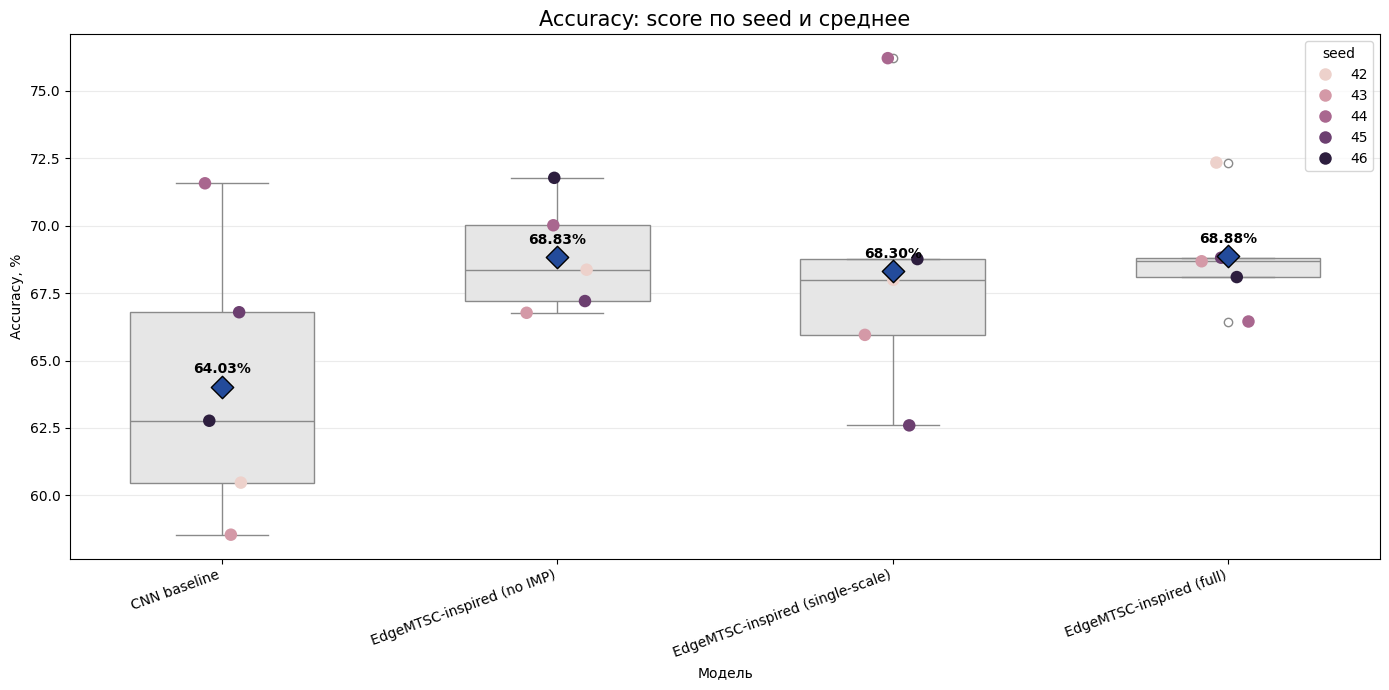

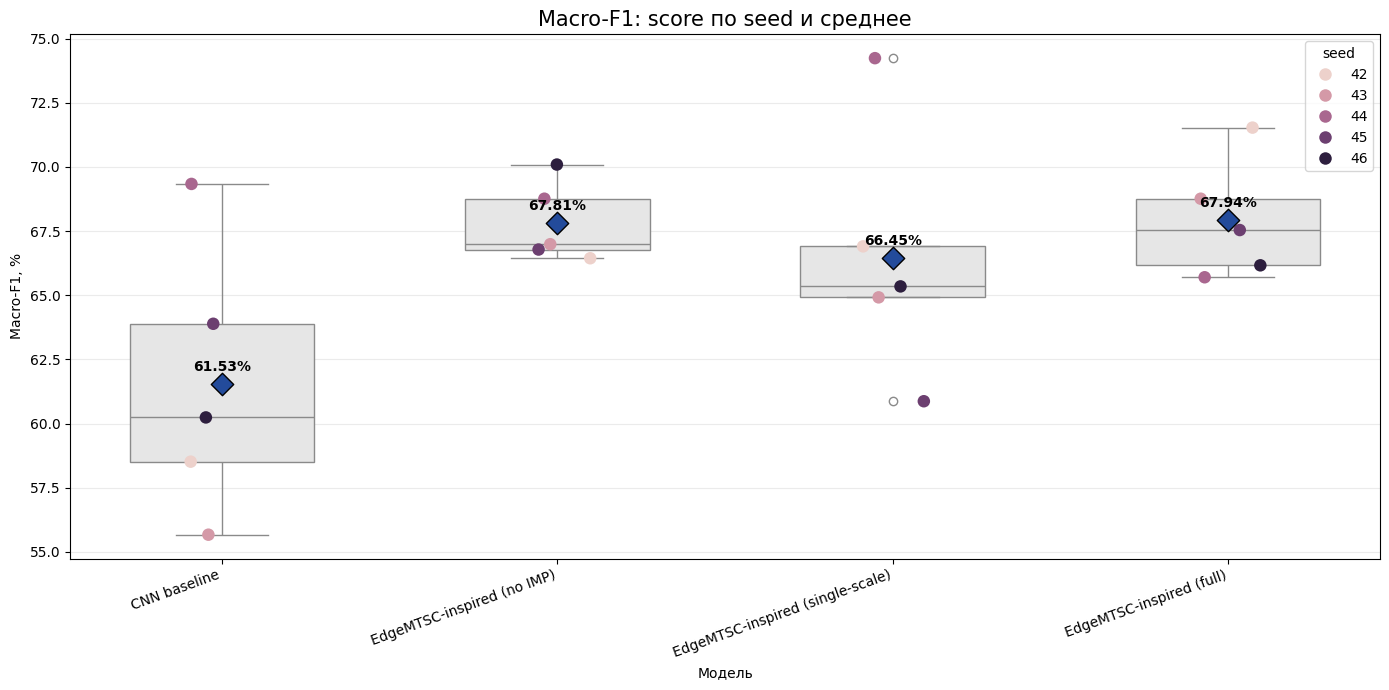

In [35]:
import seaborn as sns


for metric, metric_name in {
    "accuracy": "Accuracy",
    "macro_f1": "Macro-F1"
}.items():

    plot_df = runs_df.copy()
    plot_df[metric] *= 100

    plt.figure(figsize=(14, 7))

    sns.boxplot(
        data=plot_df,
        x="model",
        y=metric,
        color="#E6E6E6",
        width=0.55
    )

    sns.stripplot(
        data=plot_df,
        x="model",
        y=metric,
        hue="seed",
        dodge=False,
        size=9
    )

    # Среднее каждой модели
    means = (
        plot_df
        .groupby("model")[metric]
        .mean()
    )

    for i, model in enumerate(models):
        plt.scatter(
            i,
            means[model],
            marker="D",
            s=130,
            color="#234B9B",
            edgecolor="black",
            zorder=10
        )

        plt.text(
            i,
            means[model] + 0.5,
            f"{means[model]:.2f}%",
            ha="center",
            fontweight="bold"
        )

    plt.title(
        f"{metric_name}: score по seed и среднее",
        fontsize=15
    )
    plt.xlabel("Модель")
    plt.ylabel(f"{metric_name}, %")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.25)

    plt.tight_layout()
    plt.show()

Вывод по сравнению обычной сверточной сетки, одной полной edgemtsc и 2х неполных edgemtsc одна из них "no IMP" это модель без межканального взаимодействия но с множественными взаимодействиями внутри канала: ближние, средние и дальние масштабы а вторая "single-scale" в которой уже было межканальное взаимодействие но без множественных межканальных взаимодействий, а только ядро фиксированного размера:
1. сразу видно что обычная сверточная проигрывает всем видам edgemtsc, значит что прирост к метрикам дали оба приема которые использовались в edgemtsc
2. однако все 3 модели edgemtsc показывают примерно один результат(single-scale немного проиыгрывает). хотя хотелось ожидать что полная edgemtsc будет лучше своих младших братьев.
3. наши данные достаточно простые, в них не очень много каналов и не очень большая длина самих временных рядов, поэтому усложнение модели сразу 2мя идеями(single-scale и IMP) не дали улучшения по сравнению с одиночными применениями этих идей
4. идея с multi-scale сработала чуть лучше чем IMP. возможно это случайность, но так же может быть что данные простые и в них нет сложных зависимостей между каналами, поэтому IMP получился немного слабее multi-scale